In [1]:
import zipfile
import io
import pandas as pd
import os
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np

In [2]:
zip_path = "../datasets/ERC20-stablecoins.zip"

print("Files in ERC20-stablecoins.zip:")
print("=" * 50)

with zipfile.ZipFile(zip_path, "r") as outer_zip:
    for name in outer_zip.namelist():
        if name.endswith(".csv"):
            print(f"📄 {name}")
        elif name.endswith(".zip"):
            print(f"📦 {name}")
            nested_zip_data = outer_zip.read(name)
            with zipfile.ZipFile(io.BytesIO(nested_zip_data), "r") as inner_zip:
                for inner_name in inner_zip.namelist():
                    if inner_name.endswith(".csv"):
                        print(f"  📄 {inner_name}")


Files in ERC20-stablecoins.zip:
📄 token_transfers.csv
📄 token_transfers_V2.0.0.csv
📄 token_transfers_V3.0.0.csv
📦 price_data.zip
  📄 price_data/dai_price_data.csv
  📄 price_data/pax_price_data.csv
  📄 price_data/usdc_price_data.csv
  📄 price_data/usdt_price_data.csv
  📄 price_data/ustc_price_data.csv
  📄 price_data/wluna_price_data.csv
📄 event_data.csv


In [3]:
with zipfile.ZipFile(zip_path) as z:
    for filename in z.namelist():
        if filename.startswith("token_transfers") and filename.endswith(".csv"):
            with z.open(filename) as f:
                sample = pd.read_csv(f, nrows=5)

                print(f"\n📄 File: {filename}")
                print("📋 Columns:")
                print(sample.columns.tolist())

                print("📊 First 5 rows:")
                print(sample)



📄 File: token_transfers.csv
📋 Columns:
['block_number', 'transaction_index', 'from_address', 'to_address', 'time_stamp', 'contract_address', 'value']
📊 First 5 rows:
   block_number  transaction_index  \
0      14669683                  7   
1      14669683                 45   
2      14669683                 46   
3      14669683                 47   
4      14669683                 48   

                                 from_address  \
0  0xd30b438df65f4f788563b2b3611bd6059bff4ad9   
1  0x4941834ed1428089ee76252f6f9d767e800499b0   
2  0x2c1f9a20711e14f8484a41123e20d1b06858ebea   
3  0x7784c4f53aa5f03bd6d3ca670c9d9c887cc38cb0   
4  0x66589b8278470d58d4112f3d065de0f75734312e   

                                   to_address  time_stamp  \
0  0xda816e2122a8a39b0926bfa84edd3d42477e9efd  1651105815   
1  0x28c6c06298d514db089934071355e5743bf21d60  1651105815   
2  0x28c6c06298d514db089934071355e5743bf21d60  1651105815   
3  0x3cd751e6b0078be393132286c442345e5dc49699  1651105815   
4  0

In [4]:
# Open outer zip
with zipfile.ZipFile(zip_path) as outer_zip:
    # Read nested zip into memory
    nested_zip_bytes = outer_zip.read("price_data.zip")

    # Open inner zip
    with zipfile.ZipFile(io.BytesIO(nested_zip_bytes)) as inner_zip:
        for filename in inner_zip.namelist():
            if filename.startswith("price_data/") and filename.endswith(".csv"):
                with inner_zip.open(filename) as f:
                    sample = pd.read_csv(f, nrows=5)

                    print(f"\n📄 File: {filename}")
                    print("📋 Columns:")
                    print(sample.columns.tolist())

                    print("📊 First 5 rows:")
                    print(sample)



📄 File: price_data/dai_price_data.csv
📋 Columns:
['timestamp', 'open', 'high', 'low', 'close']
📊 First 5 rows:
    timestamp    open  high     low   close
0  1648857600  0.9999     1  0.9989  1.0000
1  1648944000  1.0000     1  0.9989  0.9990
2  1649030400  0.9990     1  0.9989  0.9995
3  1649116800  0.9994     1  0.9987  0.9999
4  1649203200  0.9999     1  0.9988  0.9991

📄 File: price_data/pax_price_data.csv
📋 Columns:
['timestamp', 'open', 'high', 'low', 'close']
📊 First 5 rows:
    timestamp  open  high     low   close
0  1648857600     1     1  0.9962  1.0000
1  1648944000     1     1  0.9982  1.0000
2  1649030400     1     1  0.9975  1.0000
3  1649116800     1     1  0.9986  1.0000
4  1649203200     1     1  0.9973  0.9998

📄 File: price_data/usdc_price_data.csv
📋 Columns:
['timestamp', 'open', 'high', 'low', 'close']
📊 First 5 rows:
    timestamp    open  high     low   close
0  1648857600  0.9995     1  0.9990  0.9999
1  1648944000  1.0000     1  0.9991  0.9993
2  1649030400  

In [5]:
with zipfile.ZipFile(zip_path) as z:
    with z.open("event_data.csv") as f:
        sample = pd.read_csv(f, encoding='latin-1', nrows=5)
        print(f"\n📊 First 5 rows:")
        print(sample)


📊 First 5 rows:
                                               event   timestamp      type  \
0  BlackRock and Fidelity Back USDC in $400 Milli...  1649721600  positive   
1  Terra UST takes over BUSD to become third larg...  1650412800  positive   
2  LARGE amounts of UST selling on ANCHOR (approx...  1651881600  negative   
3  UST depegs LFG deploys assets to defend peg (7...  1651968000  negative   
4    UST Depegs again to 35 cents LUNA keeps falling  1652054400  negative   

  stablecoin  
0       usdc  
1       ustc  
2       ustc  
3       ustc  
4       ustc  


In [6]:
with zipfile.ZipFile(zip_path) as z:
    for filename in z.namelist():
        if filename.startswith("token_transfers") and filename.endswith(".csv"):
            print(f"\n=== Auditing {filename} ===")

            chunk_size = 1_000_000
            total_rows = 0
            total_missing = None
            row_hashes = set()
            duplicate_count = 0

            for chunk in pd.read_csv(z.open(filename), chunksize=chunk_size):
                # Count rows
                total_rows += len(chunk)

                # Count missing values per column
                if total_missing is None:
                    total_missing = chunk.isna().sum()
                else:
                    total_missing += chunk.isna().sum()

                # Compute hash for each row and check duplicates
                for row in chunk.itertuples(index=False, name=None):
                    h = hash(row)
                    if h in row_hashes:
                        duplicate_count += 1
                    else:
                        row_hashes.add(h)

            print(f"Total rows: {total_rows}")
            print("Missing values per column:")
            print(total_missing)
            print(f"Duplicate transactions (entire row): {duplicate_count}")
            print(f"Unique transactions (entire row): {len(row_hashes)}")



=== Auditing token_transfers.csv ===


KeyboardInterrupt: 

In [ ]:

chunk_size = 1_000_000
output_dir = "../datasets/processed/gfc_data/cleaned_csv"
os.makedirs(output_dir, exist_ok=True)

with zipfile.ZipFile(zip_path) as z:
    for filename in z.namelist():
        if filename.startswith("token_transfers") and filename.endswith(".csv"):
            print(f"\n Removing duplicates from {filename}")

            output_path = os.path.join(
                output_dir,
                filename.replace(".csv", "_cleaned.csv")
            )

            total_rows = 0
            kept_rows = 0
            seen_rows = pd.DataFrame()   # stores unique rows seen so far
            first_chunk = True

            for chunk in pd.read_csv(z.open(filename), chunksize=chunk_size):
                total_rows += len(chunk)

                # remove duplicates within chunk
                chunk = chunk.drop_duplicates(keep="first")

                # remove duplicates across previous chunks
                if not seen_rows.empty:
                    combined = pd.concat([seen_rows, chunk], ignore_index=True)
                    combined = combined.drop_duplicates(keep="first")

                    # keep only the rows that came from this chunk
                    chunk = combined.iloc[len(seen_rows):]

                # update seen rows
                seen_rows = pd.concat([seen_rows, chunk], ignore_index=True)

                kept_rows += len(chunk)

                # write incrementally
                chunk.to_csv(
                    output_path,
                    mode="w" if first_chunk else "a",
                    index=False,
                    header=first_chunk
                )
                first_chunk = False

            print(f"Total rows read: {total_rows}")
            print(f"Unique rows kept: {kept_rows}")
            print(f"Duplicates removed: {total_rows - kept_rows}")
            print(f"Saved to: {output_path}")



 Removing duplicates from token_transfers.csv
Total rows read: 5280131
Unique rows kept: 5279133
Duplicates removed: 998
Saved to: cleaned_csv\token_transfers_cleaned.csv

 Removing duplicates from token_transfers_V2.0.0.csv
Total rows read: 28674511
Unique rows kept: 28663732
Duplicates removed: 10779
Saved to: cleaned_csv\token_transfers_V2.0.0_cleaned.csv

 Removing duplicates from token_transfers_V3.0.0.csv
Total rows read: 36723655
Unique rows kept: 36711134
Duplicates removed: 12521
Saved to: cleaned_csv\token_transfers_V3.0.0_cleaned.csv


In [9]:

chunk_size = 1_000_000
output_dir = "../datasets/processed/erc_20/cleaned_csv"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "event_data_cleaned.csv")

with zipfile.ZipFile(zip_path) as z:
    print("\n=== Cleaning event_data.csv ===")

    total_rows = 0
    kept_rows = 0
    total_missing = None
    seen_rows = pd.DataFrame()   # stores unique rows seen so far
    first_chunk = True

    with z.open("event_data.csv") as f:
        for chunk in pd.read_csv(f, chunksize=chunk_size, encoding="latin-1"):
            total_rows += len(chunk)

            # 1️⃣ Missing values
            if total_missing is None:
                total_missing = chunk.isna().sum()
            else:
                total_missing += chunk.isna().sum()

            # 2️⃣ Remove duplicates within chunk
            chunk = chunk.drop_duplicates(keep="first")

            # 3️⃣ Remove duplicates across previous chunks
            if not seen_rows.empty:
                combined = pd.concat([seen_rows, chunk], ignore_index=True)
                combined = combined.drop_duplicates(keep="first")

                # keep only rows originating from THIS chunk
                chunk = combined.iloc[len(seen_rows):]

            # 4️⃣ Update seen rows
            seen_rows = pd.concat([seen_rows, chunk], ignore_index=True)
            kept_rows += len(chunk)

            # 5️⃣ Write incrementally
            chunk.to_csv(
                output_path,
                mode="w" if first_chunk else "a",
                index=False,
                header=first_chunk
            )
            first_chunk = False

    print(f"Total rows read: {total_rows}")
    print("Missing values per column:")
    print(total_missing)
    print(f"Duplicates removed: {total_rows - kept_rows}")
    print(f"Unique rows kept: {kept_rows}")
    print(f"Saved to: {output_path}")



=== Cleaning event_data.csv ===
Total rows read: 38
Missing values per column:
event         0
timestamp     0
type          0
stablecoin    0
dtype: int64
Duplicates removed: 0
Unique rows kept: 38
Saved to: ../datasets/processed/erc_20/cleaned_csv\event_data_cleaned.csv


In [ ]:
chunk_size = 1_000_000
output_dir = "../datasets/processed/gfc_data/cleaned_csv_price_data"
os.makedirs(output_dir, exist_ok=True)

with zipfile.ZipFile(zip_path) as outer_zip:
    # read the nested price_data.zip into memory
    nested_bytes = outer_zip.read("price_data.zip")
    with zipfile.ZipFile(io.BytesIO(nested_bytes)) as inner_zip:
        for filename in inner_zip.namelist():
            if filename.endswith(".csv"):
                print(f"\n=== Cleaning {filename} ===")
                
                output_path = os.path.join(
                    output_dir,
                    filename.split("/")[-1].replace(".csv", "_cleaned.csv")
                )

                total_rows = 0
                kept_rows = 0
                seen_rows = pd.DataFrame()  # to track unique rows across chunks
                first_chunk = True
                total_missing = None

                with inner_zip.open(filename) as f:
                    for chunk in pd.read_csv(f, chunksize=chunk_size):
                        total_rows += len(chunk)

                        # Missing values
                        if total_missing is None:
                            total_missing = chunk.isna().sum()
                        else:
                            total_missing += chunk.isna().sum()

                        # Remove duplicates within chunk
                        chunk = chunk.drop_duplicates(keep="first")

                        # Remove duplicates across previous chunks
                        if not seen_rows.empty:
                            combined = pd.concat([seen_rows, chunk], ignore_index=True)
                            combined = combined.drop_duplicates(keep="first")

                            # keep only rows originating from THIS chunk
                            chunk = combined.iloc[len(seen_rows):]

                        # Update seen_rows
                        seen_rows = pd.concat([seen_rows, chunk], ignore_index=True)
                        kept_rows += len(chunk)

                        # Write incrementally to CSV
                        chunk.to_csv(
                            output_path,
                            mode="w" if first_chunk else "a",
                            index=False,
                            header=first_chunk
                        )
                        first_chunk = False

                print(f"Total rows read: {total_rows}")
                print("Missing values per column:")
                print(total_missing)
                print(f"Duplicates removed: {total_rows - kept_rows}")
                print(f"Unique rows kept: {kept_rows}")
                print(f"Saved to: {output_path}")



=== Cleaning price_data/dai_price_data.csv ===
Total rows read: 215
Missing values per column:
timestamp    0
open         0
high         0
low          0
close        0
dtype: int64
Duplicates removed: 0
Unique rows kept: 215
Saved to: cleaned_csv_price_data\dai_price_data_cleaned.csv

=== Cleaning price_data/pax_price_data.csv ===
Total rows read: 215
Missing values per column:
timestamp    0
open         0
high         0
low          0
close        0
dtype: int64
Duplicates removed: 0
Unique rows kept: 215
Saved to: cleaned_csv_price_data\pax_price_data_cleaned.csv

=== Cleaning price_data/usdc_price_data.csv ===
Total rows read: 215
Missing values per column:
timestamp    0
open         0
high         0
low          0
close        0
dtype: int64
Duplicates removed: 0
Unique rows kept: 215
Saved to: cleaned_csv_price_data\usdc_price_data_cleaned.csv

=== Cleaning price_data/usdt_price_data.csv ===
Total rows read: 215
Missing values per column:
timestamp    0
open         0
high   

In [ ]:
data_folder_path = "../datasets/processed/gfc_data"

# Folders with cleaned CSVs
folders = [os.path.join(data_folder_path, folder_name) for folder_name in ["cleaned_csv", "cleaned_csv_price_data"]]

for folder in folders:
    for filename in os.listdir(folder):
        if filename.endswith(".csv"):
            path = os.path.join(folder, filename)
            df = pd.read_csv(path)

            # Token transfers: time_stamp → time_stamp_dt
            if "time_stamp" in df.columns:

                df["time_stamp_dt"] = pd.to_datetime(df["time_stamp"], unit="s", utc=True)
                print(f"\n Converted time_stamp in {filename}")
                print(df["time_stamp_dt"].head(3))

            # Event data: timestamp → timestamp_dt
            elif "timestamp" in df.columns:
                df["timestamp_dt"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
                print(f"\n Converted timestamp in {filename}")
                print(df["timestamp_dt"].head(3))

            # Price data: skip if no timestamp column
            else:
                print(f"\n No timestamp column to convert in {filename}")

            # Overwrite CSV with updated timestamp column
            df.to_csv(path, index=False)



 Converted timestamp in event_data_cleaned.csv
0   2022-04-12 00:00:00+00:00
1   2022-04-20 00:00:00+00:00
2   2022-05-07 00:00:00+00:00
Name: timestamp_dt, dtype: datetime64[ns, UTC]

 Converted time_stamp in token_transfers_cleaned.csv
0   2022-04-28 00:30:15+00:00
1   2022-04-28 00:30:15+00:00
2   2022-04-28 00:30:15+00:00
Name: time_stamp_dt, dtype: datetime64[ns, UTC]

 Converted time_stamp in token_transfers_V2.0.0_cleaned.csv
0   2022-04-28 00:30:15+00:00
1   2022-04-28 00:30:15+00:00
2   2022-04-28 00:30:15+00:00
Name: time_stamp_dt, dtype: datetime64[ns, UTC]

 Converted time_stamp in token_transfers_V3.0.0_cleaned.csv
0   2022-04-01 11:10:21+00:00
1   2022-04-01 11:10:21+00:00
2   2022-04-01 11:10:21+00:00
Name: time_stamp_dt, dtype: datetime64[ns, UTC]

 Converted timestamp in dai_price_data_cleaned.csv
0   2022-04-02 00:00:00+00:00
1   2022-04-03 00:00:00+00:00
2   2022-04-04 00:00:00+00:00
Name: timestamp_dt, dtype: datetime64[ns, UTC]

 Converted timestamp in pax_price_d

In [ ]:

# Mapping of contract addresses → token names
TOKEN_MAP = {
    "0x6b175474e89094c44da98b954eedeac495271d0f": "DAI",
    "0x8e870d67f660d95d5be530380d0ec0bd388289e1": "PAX",
    "0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48": "USDC",
    "0xdac17f958d2ee523a2206206994597c13d831ec7": "USDT",
    "0xa47c8bf37f92abed4a126bda807a7b7498661acd": "USTC",
    "0xd2877702675e6ceb975b4a1dff9fb7baf4c91ea9": "WLUNA",
}

folder = "../datasets/processed/gfc_data/cleaned_csv"
chunk_size = 1_000_000

# Get all cleaned token transfer CSVs
files = sorted([
    f for f in os.listdir(folder)
    if f.startswith("token_transfers") and f.endswith(".csv")
])

for filename in files:
    path = os.path.join(folder, filename)
    # Unique temp file per run to avoid conflicts
    temp_path = os.path.join(folder, f"{filename}.tmp_tokenmap.csv")

    print(f"\n  Adding token column to {filename}")

    first_chunk = True

    # Read and process in chunks
    for chunk in pd.read_csv(path, chunksize=chunk_size):
        # Map contract_address → token
        chunk["token"] = chunk["contract_address"].map(TOKEN_MAP)

        # Write to temp file
        chunk.to_csv(temp_path, mode="w" if first_chunk else "a", index=False, header=first_chunk)
        first_chunk = False

    # Replace original file safely
    os.replace(temp_path, path)
    print(f" Token column added and file updated: {path}")



  Adding token column to token_transfers_V2.0.0_cleaned.csv
 Token column added and file updated: cleaned_csv\token_transfers_V2.0.0_cleaned.csv

  Adding token column to token_transfers_V3.0.0_cleaned.csv
 Token column added and file updated: cleaned_csv\token_transfers_V3.0.0_cleaned.csv

  Adding token column to token_transfers_cleaned.csv
 Token column added and file updated: cleaned_csv\token_transfers_cleaned.csv


In [ ]:
# Folder with cleaned token transfer CSVs
folder = "../datasets/processed/gfc_data/cleaned_csv"
files = sorted([f for f in os.listdir(folder)
                if f.startswith("token_transfers") and f.endswith("_cleaned.csv")])

chunk_size = 1_000_000

# Containers indexed by VARIABLE → FILE
value_stats = defaultdict(lambda: {"min": np.inf, "max": -np.inf, "sum": 0.0, "count": 0})
time_stats = defaultdict(lambda: {"min": pd.Timestamp.max.tz_localize("UTC"),
                                  "max": pd.Timestamp.min.tz_localize("UTC")})
token_counts = defaultdict(Counter)

for filename in files:
    path = os.path.join(folder, filename)
    print(f"\n=== Processing {filename} ===")

    for chunk in pd.read_csv(path, chunksize=chunk_size, parse_dates=["time_stamp_dt"]):
        # Ensure timestamps are tz-aware (UTC)
        if chunk["time_stamp_dt"].dt.tz is None:
            chunk["time_stamp_dt"] = chunk["time_stamp_dt"].dt.tz_localize("UTC")

        # Timestamp range
        time_stats[filename]["min"] = min(time_stats[filename]["min"], chunk["time_stamp_dt"].min())
        time_stats[filename]["max"] = max(time_stats[filename]["max"], chunk["time_stamp_dt"].max())



=== Processing token_transfers_V2.0.0_cleaned.csv ===

=== Processing token_transfers_V3.0.0_cleaned.csv ===

=== Processing token_transfers_cleaned.csv ===


In [ ]:
# Print results
print("\n=== Timestamp Ranges ===")
for f in files:
    stats = time_stats[f]
    print(f"{f}: earliest={stats['min']}, latest={stats['max']}")


=== Timestamp Ranges ===
token_transfers_V2.0.0_cleaned.csv: earliest=2022-04-28 00:30:15+00:00, latest=2022-10-07 02:38:47+00:00
token_transfers_V3.0.0_cleaned.csv: earliest=2022-04-01 11:10:21+00:00, latest=2022-11-01 04:53:59+00:00
token_transfers_cleaned.csv: earliest=2022-04-28 00:30:15+00:00, latest=2022-05-25 18:47:44+00:00


In [ ]:
folder = "../datasets/processed/gfc_data/cleaned_csv"

orig_file = os.path.join(folder, "token_transfers_cleaned.csv")
v3_file   = os.path.join(folder, "token_transfers_V3.0.0_cleaned.csv")

chunk_size = 1_000_000

# Step 1: Read V3 in chunks and store row hashes
v3_hashes = set()
print("Building hash set for V3...")
for chunk in pd.read_csv(v3_file, chunksize=chunk_size):
    for row in chunk.itertuples(index=False, name=None):
        v3_hashes.add(hash(row))
print(f"V3 contains {len(v3_hashes):,} unique rows")

# Step 2: Check each row of the original against V3 hashes
missing_count = 0
total_rows = 0
for chunk in pd.read_csv(orig_file, chunksize=chunk_size):
    for row in chunk.itertuples(index=False, name=None):
        total_rows += 1
        if hash(row) not in v3_hashes:
            missing_count += 1

print(f"\nOriginal file total rows: {total_rows:,}")
print(f"Rows missing in V3: {missing_count:,}")

if missing_count == 0:
    print("Original file is a subset of V3")
else:
    print("Original file is NOT fully contained in V3")


Building hash set for V3...
V3 contains 36,711,134 unique rows

Original file total rows: 5,279,133
Rows missing in V3: 0
Original file is a subset of V3


In [ ]:

folder = "../datasets/processed/gfc_data/cleaned_csv"

v2_file = os.path.join(folder, "token_transfers_V2.0.0_cleaned.csv")

chunk_size = 1_000_000

missing_count = 0
total_rows = 0
for chunk in pd.read_csv(orig_file, chunksize=chunk_size):
    for row in chunk.itertuples(index=False, name=None):
        total_rows += 1
        if hash(row) not in v3_hashes:
            missing_count += 1

print(f"\n V2 total rows: {total_rows:,}")
print(f"Rows missing in V3: {missing_count:,}")

if missing_count == 0:
    print("V2 is a subset of V3")
else:
    print("V2 is NOT fully contained in V3")



 V2 total rows: 5,279,133
Rows missing in V3: 0
V2 is a subset of V3


In [ ]:
folder = "../datasets/processed/gfc_data/cleaned_csv"
v3_file = os.path.join(folder, "token_transfers_V3.0.0_cleaned.csv")

chunk_size = 1_000_000
token_counter = Counter()

print("Computing token distribution for V3...")

for chunk in pd.read_csv(v3_file, chunksize=chunk_size):
    token_counter.update(chunk["token"])

print("\nToken distribution (V3):")
for token, count in token_counter.most_common():
    print(f"{token:6} → {count:,} transfers")


Computing token distribution for V3...

Token distribution (V3):
USDT   → 19,281,237 transfers
USDC   → 14,536,266 transfers
DAI    → 2,135,469 transfers
WLUNA  → 454,126 transfers
USTC   → 237,604 transfers
PAX    → 66,432 transfers


In [ ]:
df = pd.read_csv(
    "../datasets/processed/gfc_data/cleaned_csv_price_data/usdc_price_data_cleaned.csv",
    parse_dates=["timestamp_dt"]
)

df = df.sort_values("timestamp_dt")

# Compute time differences
df["delta"] = df["timestamp_dt"].diff()

# Look at most common intervals
print(df["delta"].value_counts().head(10))


delta
1 days    214
Name: count, dtype: int64


In [ ]:

transfer_file = os.path.join("../datasets/processed/gfc_data/cleaned_csv", "token_transfers_V3.0.0_cleaned.csv")
price_folder = "../datasets/processed/gfc_data/cleaned_csv_price_data"  # contains *_price_data_cleaned.csv

# ---------------------------
# Load V3 token transfers
# ---------------------------
chunk_size = 1_000_000
transfer_chunks = []

for chunk in pd.read_csv(transfer_file, chunksize=chunk_size, parse_dates=["time_stamp_dt"]):
    # floor timestamp to date and remove time info
    chunk["date"] = chunk["time_stamp_dt"].dt.floor("D").dt.date
    # keep only needed columns
    chunk = chunk[["date", "value", "token"]]
    transfer_chunks.append(chunk)

# combine all chunks
transfers = pd.concat(transfer_chunks, ignore_index=True)
print(f"Token transfers loaded")
print(transfers.head(3))

# ---------------------------
# Load price data
# ---------------------------
price_files = [f for f in os.listdir(price_folder) if f.endswith("_cleaned.csv")]

price_dfs = []
for pf in price_files:
    path = os.path.join(price_folder, pf)
    df = pd.read_csv(path, parse_dates=["timestamp_dt"])
    # floor timestamp to date and remove time info
    df["date"] = df["timestamp_dt"].dt.floor("D").dt.date
    df = df[["date", "close"]]  # keep only date + close
    # add token name from file
    token_name = pf.split("_")[0].upper()  # dai_price_data_cleaned.csv → DAI
    df["token"] = token_name
    price_dfs.append(df)

prices = pd.concat(price_dfs, ignore_index=True)
print(f"Price data loaded")
print(prices.head(3))


Token transfers loaded
         date    value token
0  2022-04-01    800.0  USDT
1  2022-04-01    579.0  USDT
2  2022-04-01  15898.0  USDT
Price data loaded
         date   close token
0  2022-04-02  1.0000   DAI
1  2022-04-03  0.9990   DAI
2  2022-04-04  0.9995   DAI


In [4]:
# ---------------------------
# Merge transfers with price
# ---------------------------
merged = transfers.merge(
    prices,
    on=["date", "token"],
    how="left"
)

print(f"Merged dataset: {len(merged)} rows")
print(merged.head(5))

output_path = "merged.csv"
merged.to_csv(output_path, index=False)
print(f"Merged dataset saved to: {output_path}")


Merged dataset: 36711134 rows
         date         value token  close
0  2022-04-01    800.000000  USDT    NaN
1  2022-04-01    579.000000  USDT    NaN
2  2022-04-01  15898.000000  USDT    NaN
3  2022-04-01    200.929675  USDT    NaN
4  2022-04-01    651.675449  USDT    NaN
Merged dataset saved to: merged.csv


In [5]:
# Check for duplicates
duplicate_rows = merged.duplicated()
num_duplicates = duplicate_rows.sum()
print(f"Number of duplicate rows: {num_duplicates}")

# Check for missing values
missing_per_column = merged.isna().sum()
print("Missing values per column:")
print(missing_per_column)


Number of duplicate rows: 16548470
Missing values per column:
date         0
value        0
token        0
close    95412
dtype: int64


In [6]:
merged[merged["close"].isna()][["date", "token"]].drop_duplicates().head(10)


,date,token
0,2022-04-01,USDT
14,2022-04-01,USDC
64,2022-04-01,DAI
66,2022-04-01,USTC
230,2022-04-01,WLUNA
532,2022-04-01,PAX


In [7]:
merged = merged.dropna(subset=["close"])

In [ ]:

stablecoins = ["USTC", "USDT", "USDC", "DAI", "PAX"]

# Peg definition (stablecoins only)
merged["peg"] = merged["token"].apply(
    lambda x: 1.0 if x in stablecoins else np.nan
)

# Stablecoin price deviation
merged["price_deviation"] = merged["close"] - merged["peg"]

# Stablecoin loss exposure
merged["loss_exposure"] = np.where(
    merged["token"].isin(stablecoins),
    merged["value"] * (merged["price_deviation"].abs()),
    np.nan
)


In [9]:
daily_stable_loss = (
    merged[merged["token"].isin(stablecoins)]
    .groupby(["date", "token"])
    .agg(
        total_value=("value", "sum"),
        loss_exposure=("loss_exposure", "sum"),
        avg_price=("close", "mean")
    )
    .reset_index()
)

daily_stable_loss["date"] = pd.to_datetime(daily_stable_loss["date"])


daily_stable_loss["loss_pct"] = (
    daily_stable_loss["loss_exposure"] / daily_stable_loss["total_value"]
)

In [10]:
base_folder = "crisis_plots"
daily_folder = os.path.join(base_folder, "daily")
monthly_folder = os.path.join(base_folder, "monthly")

# Create folders if they don't exist
os.makedirs(daily_folder, exist_ok=True)
os.makedirs(monthly_folder, exist_ok=True)

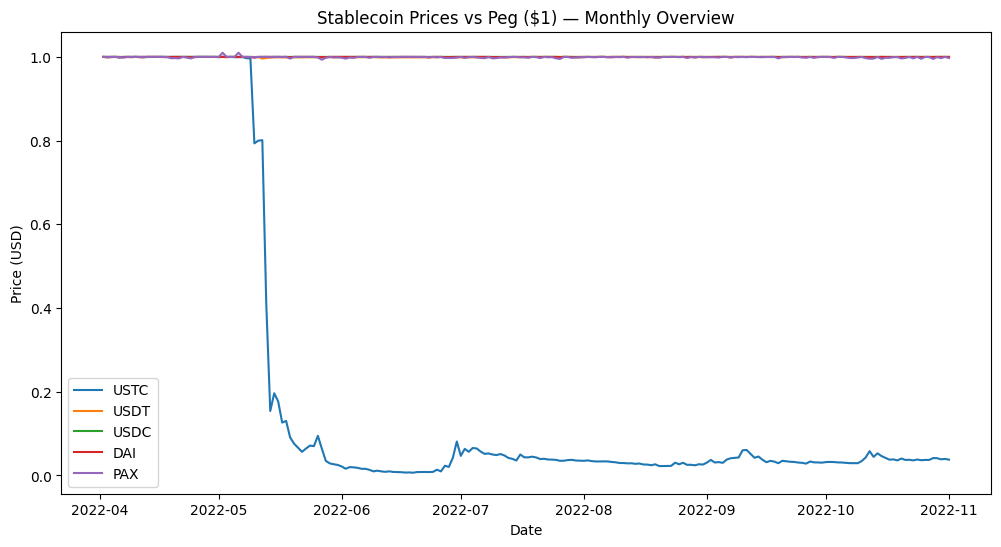

In [ ]:

stable_price_panel = (
    daily_stable_loss
    .pivot(index="date", columns="token", values="avg_price")
)

plt.figure(figsize=(12, 6))
for token in stablecoins:
    token_prices = stable_price_panel[token]
    plt.plot(token_prices.index, token_prices.values, label=token)

plt.title("Stablecoin Prices vs Peg ($1) — Monthly Overview")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.legend()
plt.savefig(os.path.join(monthly_folder, "stablecoin_prices_monthly.png"))
plt.show()
plt.close()


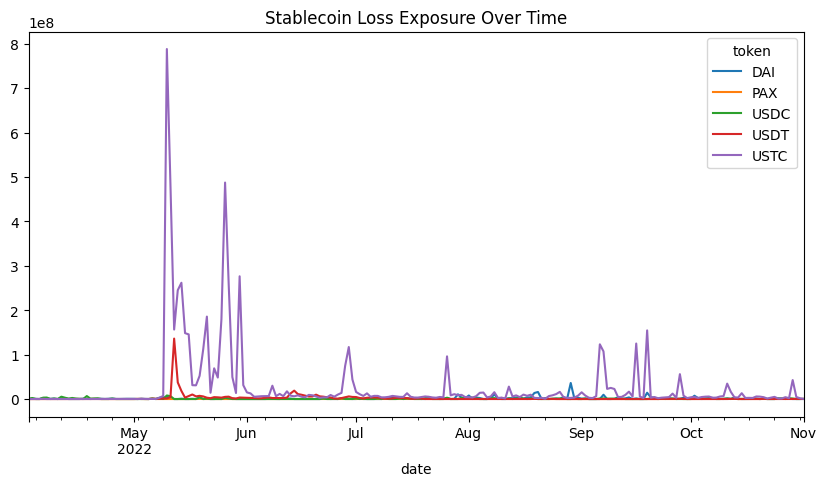

In [12]:
stable_loss_panel = (
    daily_stable_loss
    .pivot(index="date", columns="token", values="loss_exposure")
)

stable_loss_panel.plot(
    figsize=(10, 5),
    title="Stablecoin Loss Exposure Over Time"
)

plt.savefig(os.path.join(monthly_folder, "stablecoin_loss_exposure_monthly.png"))
plt.show()
plt.close()



In [13]:
# WLUNA-only dataframe
wluna = merged[merged["token"] == "WLUNA"].copy()

# Sort for time-series operations
wluna = wluna.sort_values("date")

# Daily price change
wluna["price_change"] = wluna["close"].diff()

# WLUNA loss exposure (value-weighted price movement)
wluna["wluna_loss_exposure"] = wluna["value"] * wluna["price_change"].abs()


In [14]:
daily_wluna_loss = (
    wluna
    .groupby("date")
    .agg(
        total_value=("value", "sum"),
        avg_price=("close", "mean"),
        wluna_loss_exposure=("wluna_loss_exposure", "sum")
    )
    .reset_index()
)

daily_wluna_loss["loss_pct"] = daily_wluna_loss["wluna_loss_exposure"] / daily_wluna_loss["total_value"]

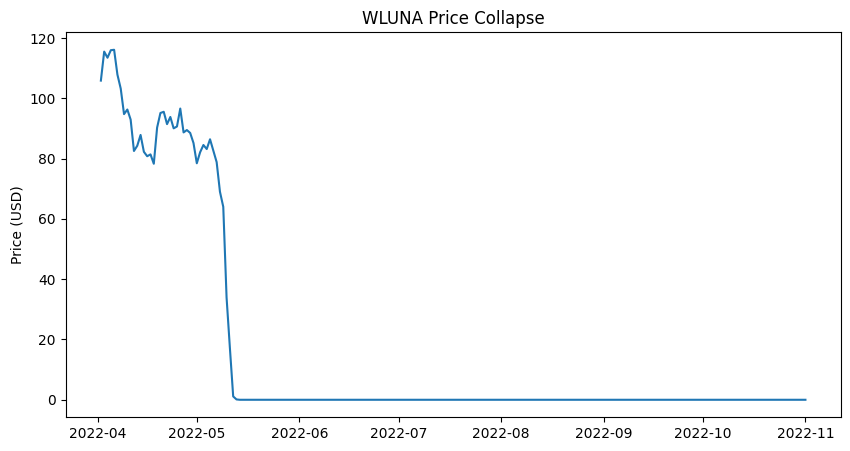

In [ ]:

plt.figure(figsize=(10, 5))
plt.plot(daily_wluna_loss["date"], daily_wluna_loss["avg_price"])
plt.title("WLUNA Price Collapse")
plt.ylabel("Price (USD)")
plt.savefig(os.path.join(monthly_folder, "wluna_price_collapse_monthly.png"))
plt.show()
plt.close()


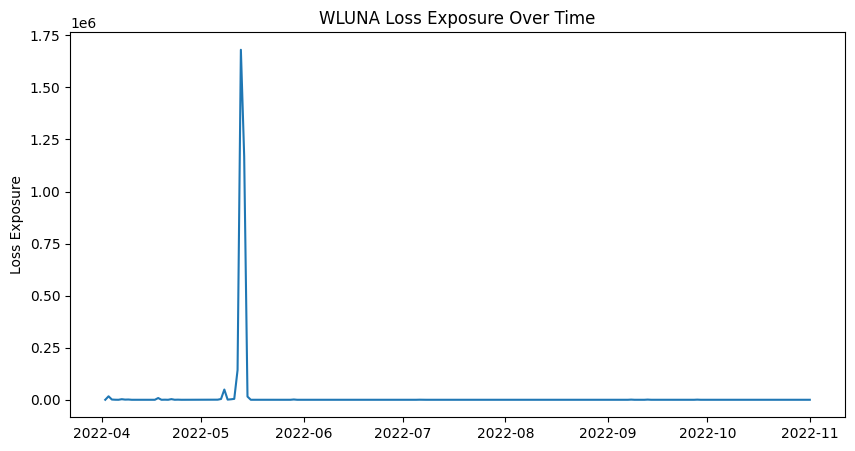

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(daily_wluna_loss["date"], daily_wluna_loss["wluna_loss_exposure"])
plt.title("WLUNA Loss Exposure Over Time")
plt.ylabel("Loss Exposure") 
plt.savefig(os.path.join(monthly_folder, "wluna_loss_exposure_monthly.png"))
plt.show()
plt.close()


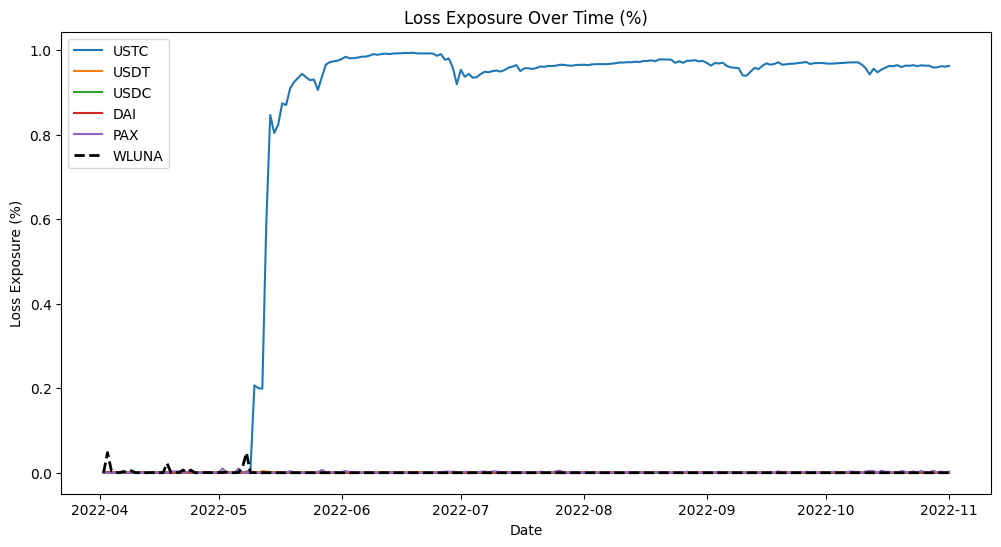

In [ ]:
# Stablecoins pivot
stable_loss_panel = daily_stable_loss.pivot(index="date", columns="token", values="loss_pct")

# WLUNA loss_pct series
wluna_loss_pct = daily_wluna_loss.set_index("date")["loss_pct"]

plt.figure(figsize=(12,6))

# Stablecoins
for token in stablecoins:
    plt.plot(stable_loss_panel.index, stable_loss_panel[token], label=token)

# WLUNA
plt.plot(wluna_loss_pct.index, wluna_loss_pct, label="WLUNA", color='black', linestyle='--', linewidth=2)

plt.title("Loss Exposure Over Time (%)")
plt.ylabel("Loss Exposure (%)")
plt.xlabel("Date")
plt.legend()
plt.savefig(os.path.join(monthly_folder, "overall_loss_exposure(%)_monthly.png"))
plt.show()
plt.close()


In [19]:
# Aggregate total stablecoin loss per day
daily_total_stable_loss = (
    daily_stable_loss
    .groupby("date")["loss_exposure"]
    .sum()
    .reset_index()
)

# Define crisis threshold (e.g. top 5%)
threshold = daily_total_stable_loss["loss_exposure"].quantile(0.95)

crisis_days = daily_total_stable_loss.loc[
    daily_total_stable_loss["loss_exposure"] >= threshold, "date"
]

crisis_start = crisis_days.min()
crisis_end = crisis_days.max()


print(f"\nCrisis start:") 
print(crisis_start.date())
print(f"\nCrisis end:") 
print(crisis_end.date())  


Crisis start:
2022-05-10

Crisis end:
2022-09-19


In [20]:
crisis_days = crisis_days.sort_values().reset_index(drop=True)

gaps = crisis_days.diff().dt.days

# Identify first large gap
break_idx = gaps[gaps > 7].index.min()

# Define core window
if pd.notna(break_idx):
    core_crisis_days = crisis_days.loc[:break_idx - 1]
else:
    core_crisis_days = crisis_days

core_start = core_crisis_days.min().date()
core_end = core_crisis_days.max().date()

print(f"\nCore crisis start:")
print(core_start)
print(f"\nCore crisis end:")
print(core_end)



Core crisis start:
2022-05-10

Core crisis end:
2022-05-30


In [21]:
# Restrict window
merged["date"] = pd.to_datetime(merged["date"])

crisis_data = merged[
    (merged["date"] >= pd.to_datetime("2022-05-10")) &
    (merged["date"] <= pd.to_datetime("2022-05-30"))
]

In [23]:
# Ensure merged date is pandas Timestamp (tz-naive)
merged["date"] = pd.to_datetime(merged["date"])

daily_stable_loss["date"] = pd.to_datetime(daily_stable_loss["date"])
daily_wluna_loss["date"] = pd.to_datetime(daily_wluna_loss["date"])

In [24]:
stablecoins = ["USTC", "USDT", "USDC", "DAI", "PAX"]

crisis_stable = (
    crisis_data[crisis_data["token"].isin(stablecoins)]
    .groupby(["date", "token"])
    .agg(
        total_value=("value", "sum"),
        loss_exposure=("loss_exposure", "sum"),
        avg_price=("close", "mean")
    )
    .reset_index()
)

crisis_stable["loss_pct"] = (
    crisis_stable["loss_exposure"] / crisis_stable["total_value"]
)


In [25]:
crisis_loss_by_token = (
    crisis_stable
    .groupby("token")["loss_exposure"]
    .sum()
    .sort_values(ascending=False)
)

print(crisis_loss_by_token)

token
USTC    4.032336e+09
USDT    2.690064e+08
USDC    2.280238e+07
DAI     1.425406e+07
PAX     6.603814e+05
Name: loss_exposure, dtype: float64


In [26]:
wluna_baseline = (
    merged[
        (merged["token"] == "WLUNA") &
        (merged["date"] < pd.Timestamp("2022-05-10"))
    ]["close"]
    .mean()
)

print("WLUNA baseline price:", wluna_baseline)

WLUNA baseline price: 89.7861736316148


In [27]:
merged["wluna_loss_exposure"] = 0.0

wluna_mask = merged["token"] == "WLUNA"

merged.loc[wluna_mask, "wluna_loss_exposure"] = (
    merged.loc[wluna_mask, "value"] *
    (wluna_baseline - merged.loc[wluna_mask, "close"]).clip(lower=0)
)

In [28]:
crisis_wluna = (
    merged[
        (merged["token"] == "WLUNA") &
        (merged["date"] >= pd.Timestamp("2022-05-10")) &
        (merged["date"] <= pd.Timestamp("2022-05-30"))
    ]
    .groupby("date")
    .agg(
        total_value=("value", "sum"),
        avg_price=("close", "mean"),
        wluna_loss_exposure=("wluna_loss_exposure", "sum")
    )
    .reset_index()
)

crisis_wluna["wluna_loss_pct"] = (
    crisis_wluna["wluna_loss_exposure"] / crisis_wluna["total_value"]
)


In [29]:
print(crisis_wluna[["date", "avg_price", "wluna_loss_pct"]].head())


        date  avg_price  wluna_loss_pct
0 2022-05-10  33.930000       55.856174
1 2022-05-11  17.230000       72.556174
2 2022-05-12   1.110000       88.676174
3 2022-05-13   0.114700       89.671474
4 2022-05-14   0.000115       89.786059


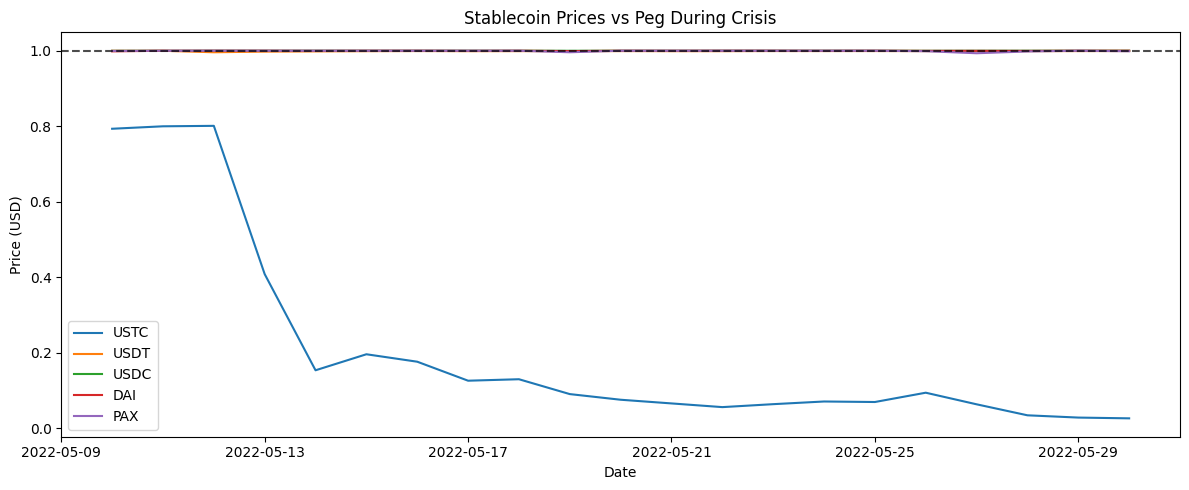

In [ ]:

stable_price_panel = (
    crisis_stable
    .pivot(index="date", columns="token", values="avg_price")
)

plt.figure(figsize=(12, 5))
for token in stablecoins:
    plt.plot(
        stable_price_panel.index,
        stable_price_panel[token],
        label=token
    )

plt.axhline(1, color="black", linestyle="--", alpha=0.7)
plt.title("Stablecoin Prices vs Peg During Crisis")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(daily_folder, "stablecoin_prices_crisis.png"))
plt.show()
plt.close()


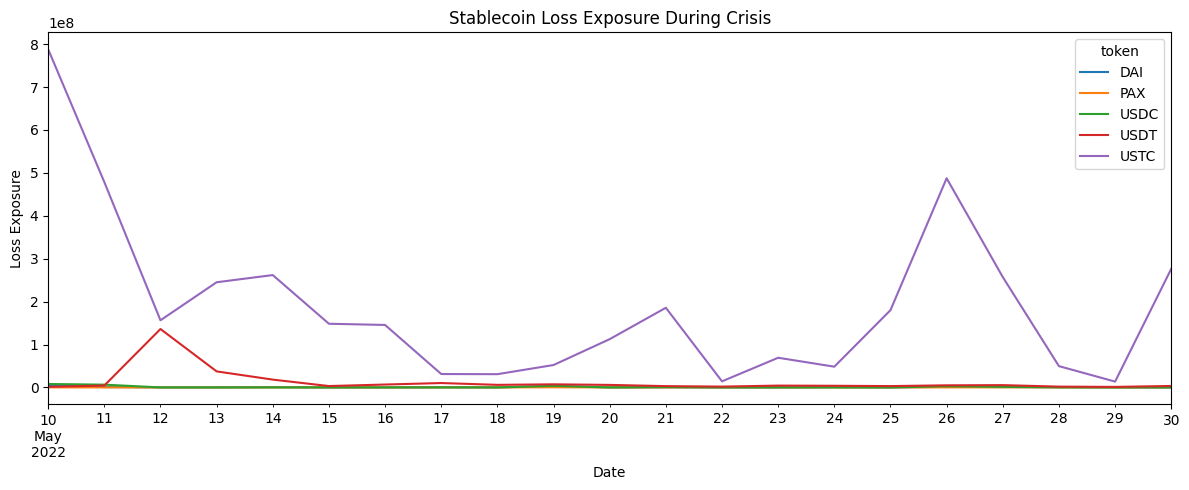

In [31]:
stable_loss_panel = (
    crisis_stable
    .pivot(index="date", columns="token", values="loss_exposure")
)

stable_loss_panel.plot(
    figsize=(12, 5),
    title="Stablecoin Loss Exposure During Crisis"
)

plt.ylabel("Loss Exposure")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig(os.path.join(daily_folder, "stablecoin_loss_exposure_crisis.png"))
plt.show()
plt.close()


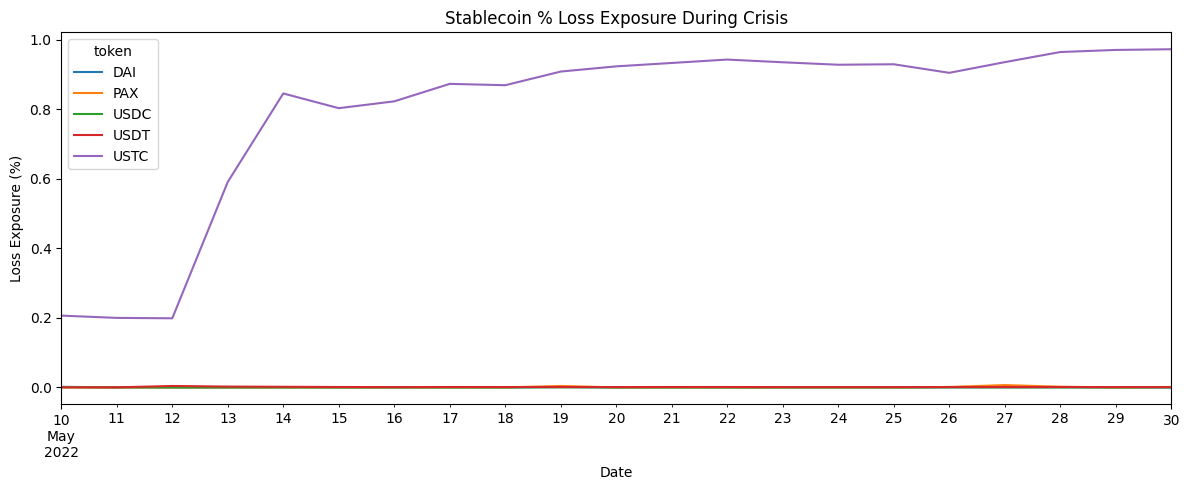

In [32]:
stable_loss_pct_panel = (
    crisis_stable
    .pivot(index="date", columns="token", values="loss_pct")
)

stable_loss_pct_panel.plot(
    figsize=(12, 5),
    title="Stablecoin % Loss Exposure During Crisis"
)

plt.ylabel("Loss Exposure (%)")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig(os.path.join(daily_folder, "stablecoin_loss_exposure(%)_crisis.png"))
plt.show()
plt.close()


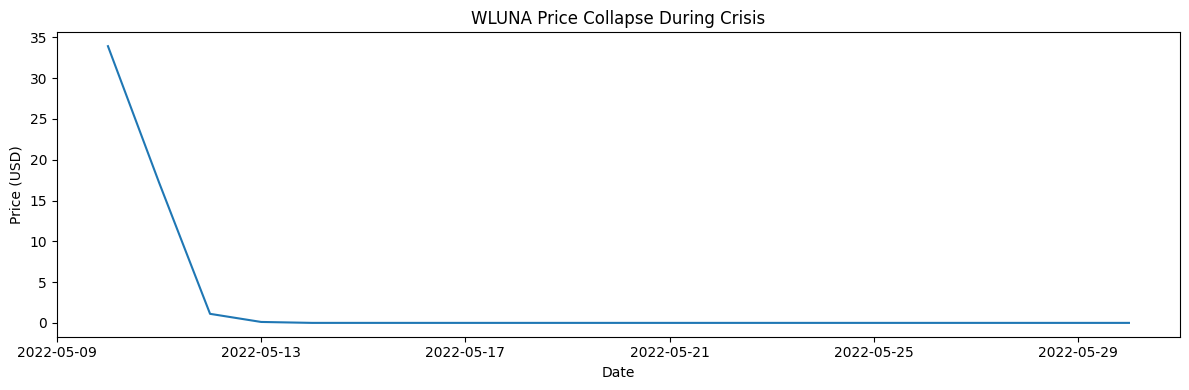

In [33]:
plt.figure(figsize=(12, 4))
plt.plot(crisis_wluna["date"], crisis_wluna["avg_price"])
plt.title("WLUNA Price Collapse During Crisis")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig(os.path.join(daily_folder, "wluna_price_collapse_crisis.png"))
plt.show()
plt.close()


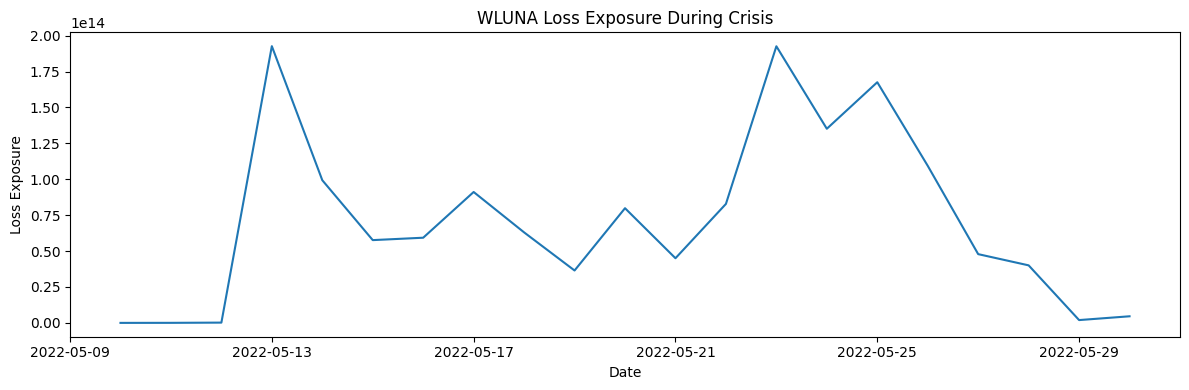

In [34]:
plt.figure(figsize=(12, 4))
plt.plot(
    crisis_wluna["date"],
    crisis_wluna["wluna_loss_exposure"]
)

plt.title("WLUNA Loss Exposure During Crisis")
plt.ylabel("Loss Exposure")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig(os.path.join(daily_folder, "wluna_loss_exposure_crisis.png"))
plt.show()
plt.close()


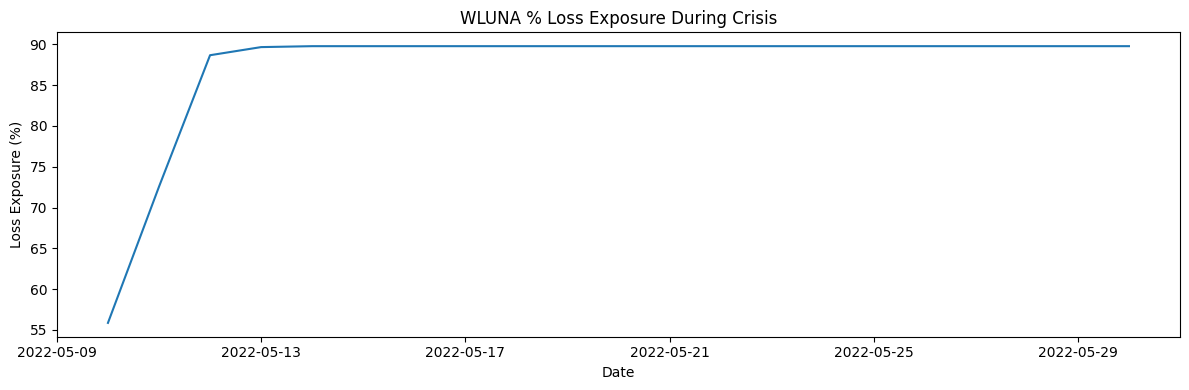

In [35]:
plt.figure(figsize=(12, 4))
plt.plot(
    crisis_wluna["date"],
    crisis_wluna["wluna_loss_pct"]
)

plt.title("WLUNA % Loss Exposure During Crisis")
plt.ylabel("Loss Exposure (%)")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig(os.path.join(daily_folder, "wluna_loss_exposure(%)_crisis.png"))
plt.show()
plt.close()


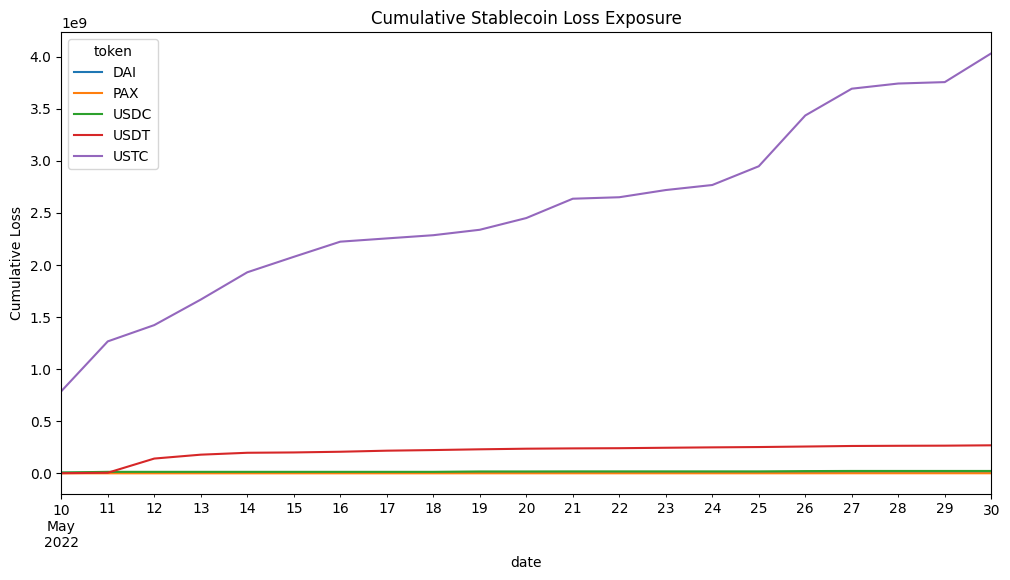

In [36]:
crisis_stable["cumulative_loss"] = (
    crisis_stable
    .sort_values("date")
    .groupby("token")["loss_exposure"]
    .cumsum()
)

cum_panel = crisis_stable.pivot(
    index="date", columns="token", values="cumulative_loss"
)

cum_panel.plot(
    figsize=(12, 6),
    title="Cumulative Stablecoin Loss Exposure"
)

plt.ylabel("Cumulative Loss")
plt.savefig(os.path.join(daily_folder, "cumulative_stablecoin_loss_exposure_crisis.png"))
plt.show()
plt.close()



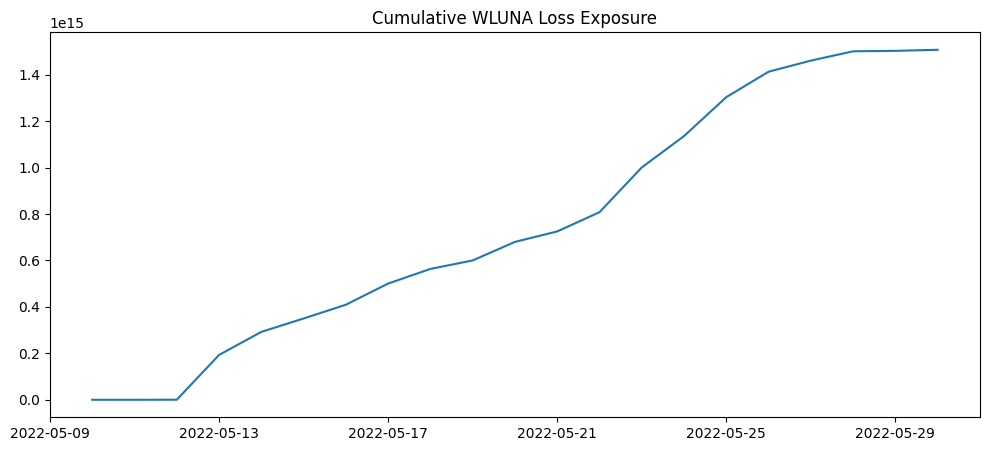

In [37]:
crisis_wluna["cumulative_loss"] = crisis_wluna["wluna_loss_exposure"].cumsum()

plt.figure(figsize=(12, 5))
plt.plot(crisis_wluna["date"], crisis_wluna["cumulative_loss"])
plt.title("Cumulative WLUNA Loss Exposure")
plt.savefig(os.path.join(daily_folder, "cumulative_wluna_loss_exposure_crisis.png"))
plt.show()
plt.close()


In [38]:
# % loss exposure per token during crisis
token_loss_pct = (
    crisis_data
    .groupby("token")
    .apply(lambda x: x["loss_exposure"].sum() / x["value"].sum())
    .reset_index(name="loss_pct")
)

token_loss_pct["loss_pct"] *= 100  # convert to %

token_loss_pct = token_loss_pct.sort_values("loss_pct", ascending = False)

print(token_loss_pct)


   token   loss_pct
4   USTC  40.222871
3   USDT   0.165014
1    PAX   0.043589
0    DAI   0.021994
2   USDC   0.006956
5  WLUNA   0.000000


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8624\1826446210.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["loss_exposure"].sum() / x["value"].sum())


In [ ]:
# Aggregate total stablecoin loss per day

daily_total_stable_loss = (
    daily_stable_loss
    .groupby("date")["loss_exposure"]
    .sum()
    .reset_index()
)

# Top 5% loss days
threshold = daily_total_stable_loss["loss_exposure"].quantile(0.95)

key_loss_days = daily_total_stable_loss.loc[
    daily_total_stable_loss["loss_exposure"] >= threshold, "date"
]

events_sorted = (
    events.sort_values("timestamp_dt").reset_index(drop=True)
)
    
key_events = events_sorted.loc[
    (events_sorted["date"].isin(key_loss_days)) &
    (events_sorted["stablecoin"].str.upper().isin(stablecoins)) &
    (events_sorted["type"] == "negative")
].copy()

key_events[["date", "event", "stablecoin"]]


,date,event,stablecoin
6,2022-05-12,UST Downfall Brings Record Volumes to Curve: I...,ustc


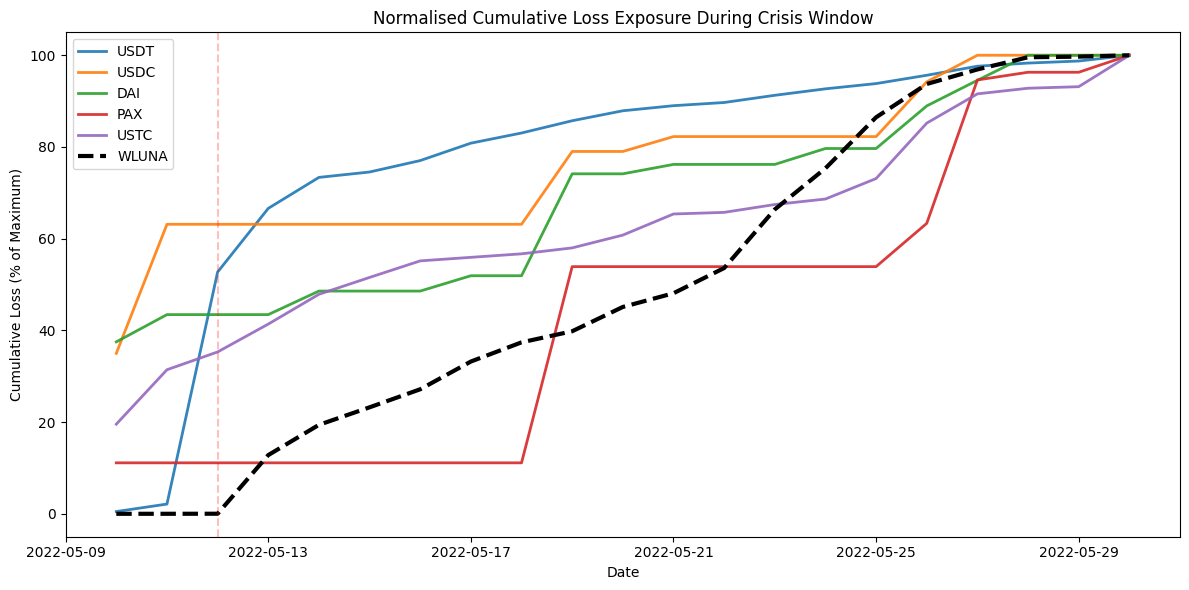

In [ ]:

# --- Ensure copies ---
crisis_wluna = crisis_wluna.copy()
crisis_stable = crisis_stable.copy()

# Ensure datetime
crisis_wluna["date"] = pd.to_datetime(crisis_wluna["date"])
crisis_stable["date"] = pd.to_datetime(crisis_stable["date"])
key_events["date"] = pd.to_datetime(key_events["date"])

# -----------------------------
# WLUNA cumulative loss
# -----------------------------
crisis_wluna = crisis_wluna.sort_values("date")
crisis_wluna["cumulative_loss"] = crisis_wluna["wluna_loss_exposure"].cumsum()

crisis_wluna["norm_cumulative_loss"] = (
    crisis_wluna["cumulative_loss"] /
    crisis_wluna["cumulative_loss"].max()
) * 100

# -----------------------------
# Stablecoins cumulative loss (per token)
# -----------------------------
crisis_stable = crisis_stable.sort_values("date")

crisis_stable["cumulative_loss"] = (
    crisis_stable
    .groupby("token")["loss_exposure"]
    .cumsum()
)

crisis_stable["norm_cumulative_loss"] = (
    crisis_stable["cumulative_loss"] /
    crisis_stable.groupby("token")["cumulative_loss"].transform("max")
) * 100

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))

# Stablecoins
for token in stablecoins:
    token_data = crisis_stable[crisis_stable["token"] == token]
    plt.plot(
        token_data["date"],
        token_data["norm_cumulative_loss"],
        label=token,
        linewidth=2,
        alpha=0.9
    )

# WLUNA (distinct)
plt.plot(
    crisis_wluna["date"],
    crisis_wluna["norm_cumulative_loss"],
    label="WLUNA",
    linestyle="--",
    linewidth=3,
    color="black"
)

# -----------------------------
# Event lines (key negative events)
# -----------------------------
for d in key_events["date"].unique():
    plt.axvline(
        d,
        color="red",
        linestyle="--",
        alpha=0.25
    )

plt.title("Normalised Cumulative Loss Exposure During Crisis Window")
plt.xlabel("Date")
plt.ylabel("Cumulative Loss (% of Maximum)")
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(daily_folder, "normalised_cumulative_loss_stablecoins_vs_wluna.png"),
    dpi=300
)
plt.show()
plt.close()


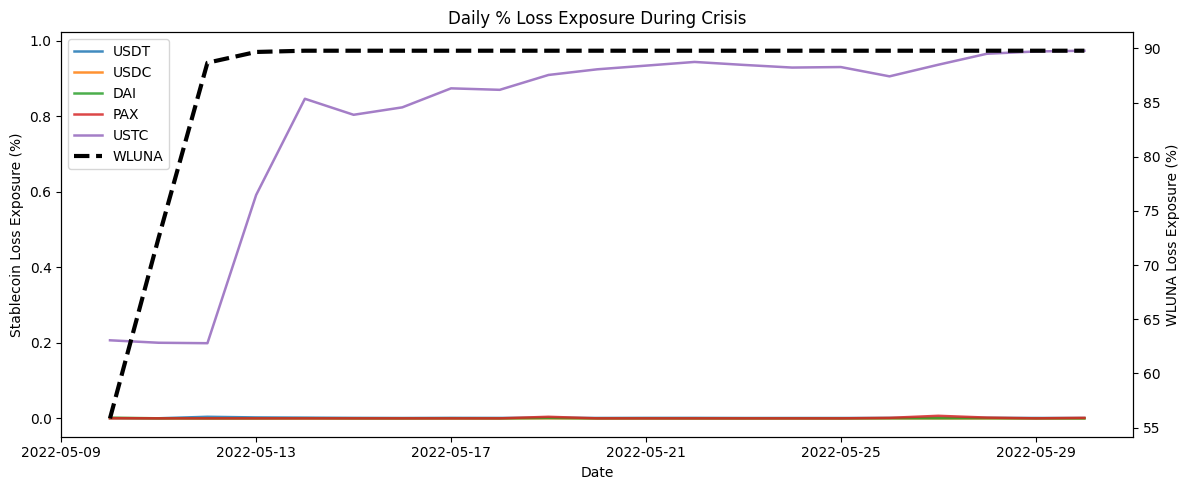

In [60]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Stablecoins on left y-axis
for token in stablecoins:
    token_data = crisis_stable[crisis_stable["token"] == token]
    ax1.plot(
        token_data["date"],
        token_data["loss_pct"],
        label=token,
        linewidth=1.8,
        alpha=0.85
    )

ax1.set_ylabel("Stablecoin Loss Exposure (%)")
ax1.set_xlabel("Date")

# WLUNA on right y-axis
ax2 = ax1.twinx()
ax2.plot(
    crisis_wluna["date"],
    crisis_wluna["wluna_loss_pct"],
    color="black",
    linestyle="--",
    linewidth=3,
    label="WLUNA"
)
ax2.set_ylabel("WLUNA Loss Exposure (%)")

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Daily % Loss Exposure During Crisis")
plt.tight_layout()
plt.show()


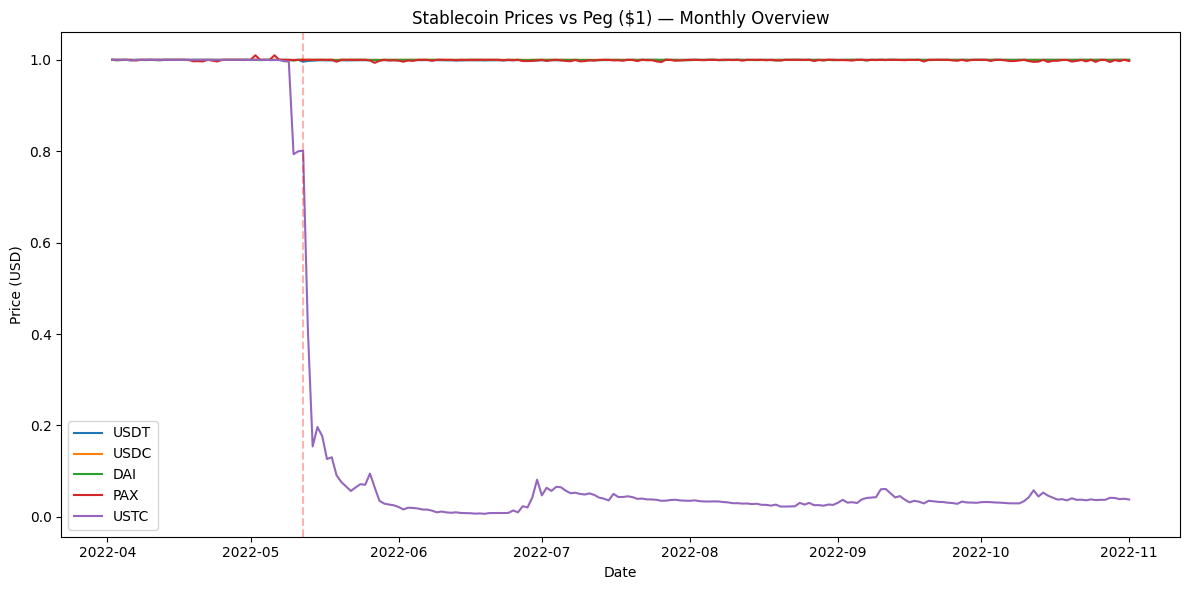

In [ ]:

stable_price_panel = (
    daily_stable_loss
    .pivot(index="date", columns="token", values="avg_price")
)

plt.figure(figsize=(12, 6))

# Plot stablecoin prices
for token in stablecoins:
    token_prices = stable_price_panel[token]
    plt.plot(token_prices.index, token_prices.values, label=token)

# Add vertical lines for key negative events
for d in pd.to_datetime(key_events["date"].unique()):
    plt.axvline(d, color='red', linestyle='--', alpha=0.3)

plt.title("Stablecoin Prices vs Peg ($1) — Monthly Overview")
plt.ylabel("Price (USD)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()

# Save figure
plt.savefig(os.path.join(monthly_folder, "stablecoin_prices_monthly_with_events.png"), dpi=300)
plt.show()
plt.close()
